# Intelligent Customer Review Analysis — McDonald's Reviews

Objectif (pour le moment) :
- Exploration et préparation des données
- Analyse statistique des données
- Visualisation des distributions
- Gestion de la normalisation / standardisation / données manquantes
- Graphe comparatif : avant vs après prétraitement
- Séparation en jeux train / validation / test

Le CSV contient : `reviewer_id`, `store_name`, `category`, `store_address`, `latitude`, `longitude`, `rating_count`, `review_time`, `review`, `rating`.

## 1) Import & configuration
Chargement des librairies et réglages d'affichage (pandas / seaborn).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

# Configuration de la colonne target pour les modèles ML
TARGET_COL = 'sentiment'  # peut être 'rating' ou 'sentiment'

## 2) Chargement des données
Lecture du fichier CSV et premier aperçu (shape + head).

In [2]:
# Chargement
DATA_PATH = Path('McDonald_s_Reviews.csv')
assert DATA_PATH.exists(), f'CSV introuvable: {DATA_PATH.resolve()}'

df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head(5))

# Remarque: dans ce dataset, certains noms de colonnes peuvent contenir des espaces (ex: "latitude "),
# et `rating`/`rating_count` peuvent être stockés en texte (ex: "4 stars", "1,240").

Shape: (33396, 10)


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was �����������...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


## 3) Exploration rapide
Types de colonnes, valeurs manquantes, et doublons.

In [3]:
# Exploration rapide
display(df_raw.info())

missing = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(missing.to_frame('missing_%').head(20))

dup_count = df_raw.duplicated().sum()
print('Duplicates:', dup_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB


None

,missing_%
latitude,1.976285
longitude,1.976285
store_name,0.000000
reviewer_id,0.000000
store_address,0.000000
category,0.000000
rating_count,0.000000
review_time,0.000000
review,0.000000
rating,0.000000


Duplicates: 0


## 4) Analyse statistique
Statistiques descriptives et agrégats (par catégorie, par store, corrélations).

In [4]:
# Analyse statistique approfondie avec comparaisons et interprétations
print('='*80)
print('  ANALYSE STATISTIQUE APPROFONDIE')
print('='*80)

# Créer une copie pour le parsing temporaire
df_analysis = df_raw.copy()

# Parser temporairement le rating pour l'analyse
def parse_rating_temp(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

# Parser temporairement rating_count pour l'analyse
def parse_rating_count_temp(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(',', '').strip()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

if 'rating' in df_analysis.columns:
    df_analysis['rating'] = df_analysis['rating'].apply(parse_rating_temp)

if 'rating_count' in df_analysis.columns:
    df_analysis['rating_count'] = df_analysis['rating_count'].apply(parse_rating_count_temp)

# ============================================================================
# 1) ANALYSE GLOBALE DES RATINGS
# ============================================================================
if 'rating' in df_analysis.columns:
    print('\n1️⃣  STATISTIQUES GLOBALES DES RATINGS')
    print('-'*80)
    
    rating_stats = df_analysis['rating'].describe()
    display(rating_stats)
    
    # Interprétations
    mean_rating = rating_stats['mean']
    median_rating = rating_stats['50%']
    std_rating = rating_stats['std']
    
    print(f'\n📊 Interprétation:')
    print(f'   • Moyenne: {mean_rating:.2f} / 5.0')
    print(f'   • Médiane: {median_rating:.2f} / 5.0')
    print(f'   • Écart-type: {std_rating:.2f}')
    
    if mean_rating > 4.0:
        print(f'   → Satisfaction globale ÉLEVÉE (moyenne > 4.0)')
    elif mean_rating > 3.0:
        print(f'   → Satisfaction globale MODÉRÉE (3.0 < moyenne ≤ 4.0)')
    else:
        print(f'   → Satisfaction globale FAIBLE (moyenne ≤ 3.0)')
    
    if abs(mean_rating - median_rating) < 0.1:
        print(f'   → Distribution relativement SYMÉTRIQUE (moyenne ≈ médiane)')
    elif mean_rating < median_rating:
        print(f'   → Distribution NÉGATIVEMENT asymétrique (tirée vers le bas)')
    else:
        print(f'   → Distribution POSITIVEMENT asymétrique (tirée vers le haut)')
    
    if std_rating < 0.5:
        print(f'   → Variabilité FAIBLE: les avis sont très homogènes')
    elif std_rating < 1.0:
        print(f'   → Variabilité MODÉRÉE: consensus relatif entre les clients')
    else:
        print(f'   → Variabilité ÉLEVÉE: opinions très divergentes')


# ============================================================================
# 2) ANALYSE PAR SENTIMENT (distribution)
# ============================================================================
if 'sentiment' in df_analysis.columns:
    print('\n\n2️⃣  DISTRIBUTION PAR SENTIMENT')
    print('-'*80)
    
    sentiment_counts = df_analysis['sentiment'].value_counts(dropna=False)
    sentiment_pct = df_analysis['sentiment'].value_counts(normalize=True, dropna=False) * 100
    
    sentiment_df = pd.DataFrame({
        'Nombre': sentiment_counts,
        'Pourcentage': sentiment_pct.apply(lambda x: f'{x:.2f}%')
    })
    display(sentiment_df)
    
    print(f'\n📊 Interprétation:')
    if 'positif' in sentiment_counts:
        pct_pos = sentiment_pct.get('positif', 0)
        pct_neg = sentiment_pct.get('négatif', 0)
        pct_neu = sentiment_pct.get('neutre', 0)
        
        print(f'   • Positif: {pct_pos:.1f}% des avis')
        print(f'   • Neutre: {pct_neu:.1f}% des avis')
        print(f'   • Négatif: {pct_neg:.1f}% des avis')
        
        # Ratio positif/négatif
        if pct_neg > 0:
            ratio = pct_pos / pct_neg
            print(f'   • Ratio Positif/Négatif: {ratio:.2f}:1')
            
            if ratio > 5:
                print(f'   → Image de marque TRÈS POSITIVE (ratio > 5:1)')
            elif ratio > 2:
                print(f'   → Image de marque POSITIVE (ratio > 2:1)')
            elif ratio > 1:
                print(f'   → Image de marque LÉGÈREMENT POSITIVE')
            else:
                print(f'   → Image de marque PROBLÉMATIQUE (plus de négatif que de positif)')


# ============================================================================
# 3) COMPARAISON PAR CATÉGORIE
# ============================================================================
if {'category', 'rating'}.issubset(df_analysis.columns):
    print('\n\n3️⃣  COMPARAISON PAR CATÉGORIE')
    print('-'*80)
    
    cat_stats = df_analysis.groupby('category', dropna=False)['rating'].agg([
        ('Nb_avis', 'count'),
        ('Moyenne', 'mean'),
        ('Médiane', 'median'),
        ('Écart-type', 'std'),
        ('Min', 'min'),
        ('Max', 'max')
    ]).round(2)
    
    cat_stats = cat_stats.sort_values('Moyenne', ascending=False)
    display(cat_stats)
    
    print(f'\n📊 Interprétation:')
    best_cat = cat_stats.index[0]
    worst_cat = cat_stats.index[-1]

# ============================================================================
# 4) TOP & FLOP MAGASINS
# ============================================================================
if {'store_address', 'rating'}.issubset(df_analysis.columns):
    print('\n\n4️⃣  TOP & FLOP MAGASINS')
    print('-'*80)
    
    store_stats = df_analysis.groupby('store_address', dropna=False)['rating'].agg([
        ('Nb_avis', 'count'),
        ('Moyenne', 'mean')
    ]).round(2)
    
    # Filtrer les magasins avec au moins 5 avis pour avoir des stats fiables
    store_stats_filtered = store_stats[store_stats['Nb_avis'] >= 5]
    
    print(f'\n📈 TOP 5 MAGASINS (meilleure moyenne, min 5 avis):')
    top5 = store_stats_filtered.sort_values('Moyenne', ascending=False).head(5)
    display(top5)
    
    print(f'\n📉 FLOP 5 MAGASINS (moins bonne moyenne, min 5 avis):')
    flop5 = store_stats_filtered.sort_values('Moyenne', ascending=True).head(5)
    display(flop5)
    
    print(f'\n📊 Interprétation:')
    best_store_avg = top5['Moyenne'].iloc[0]
    worst_store_avg = flop5['Moyenne'].iloc[0]
    gap_stores = best_store_avg - worst_store_avg
    
    print(f'   • Écart meilleur/pire magasin: {gap_stores:.2f} points')
    
    if gap_stores > 2.0:
        print(f'   → Disparités TRÈS IMPORTANTES entre magasins (écart > 2.0)')
        print(f'   → Problème de standardisation de la qualité de service')
    elif gap_stores > 1.0:
        print(f'   → Disparités MODÉRÉES entre magasins (1.0 < écart ≤ 2.0)')
    else:
        print(f'   → Qualité HOMOGÈNE entre magasins (écart ≤ 1.0)')


# ============================================================================
# 5) ANALYSE DE LA LONGUEUR DES REVIEWS
# ============================================================================
if 'review_length' in df_analysis.columns and 'rating' in df_analysis.columns:
    print('\n\n5️⃣  RELATION LONGUEUR DES REVIEWS vs RATING')
    print('-'*80)
    
    # Grouper par rating et calculer la longueur moyenne
    length_by_rating = df_analysis.groupby('rating')['review_length'].agg([
        ('Nb_reviews', 'count'),
        ('Longueur_moyenne', 'mean'),
        ('Longueur_médiane', 'median')
    ]).round(0)
    
    display(length_by_rating)
    
    # Corrélation
    corr_length_rating = df_analysis[['review_length', 'rating']].corr().loc['review_length', 'rating']
    
    print(f'\n📊 Interprétation:')
    print(f'   • Corrélation longueur/rating: {corr_length_rating:.3f}')
    
    if abs(corr_length_rating) < 0.1:
        print(f'   → Corrélation NÉGLIGEABLE: la longueur n\'influence pas le rating')
    elif corr_length_rating > 0.3:
        print(f'   → Corrélation POSITIVE: les avis longs sont plus positifs')
    elif corr_length_rating < -0.3:
        print(f'   → Corrélation NÉGATIVE: les avis longs sont plus négatifs')
    else:
        print(f'   → Corrélation FAIBLE')
    
    # Comparer extrêmes
    len_rating_1 = length_by_rating.loc[1.0, 'Longueur_moyenne'] if 1.0 in length_by_rating.index else 0
    len_rating_5 = length_by_rating.loc[5.0, 'Longueur_moyenne'] if 5.0 in length_by_rating.index else 0
    
    if len_rating_1 > 0 and len_rating_5 > 0:
        if len_rating_1 > len_rating_5:
            pct_diff = ((len_rating_1 - len_rating_5) / len_rating_5) * 100
            print(f'   • Les avis 1★ sont {pct_diff:.0f}% plus longs que les avis 5★')
            print(f'   → Les clients mécontents s\'expriment plus longuement')
        else:
            pct_diff = ((len_rating_5 - len_rating_1) / len_rating_1) * 100
            print(f'   • Les avis 5★ sont {pct_diff:.0f}% plus longs que les avis 1★')
            print(f'   → Les clients satisfaits s\'expriment plus longuement')


# ============================================================================
# 6) ANALYSE TEMPORELLE (ancienneté des reviews)
# ============================================================================
if 'review_time_days' in df_analysis.columns and 'rating' in df_analysis.columns:
    print('\n\n6️⃣  ÉVOLUTION TEMPORELLE DES RATINGS')
    print('-'*80)
    
    # Créer des tranches temporelles
    df_analysis['tranche_temps'] = pd.cut(df_analysis['review_time_days'], 
                                   bins=[0, 30, 90, 180, 365, float('inf')],
                                   labels=['0-30j', '1-3 mois', '3-6 mois', '6-12 mois', '>1 an'])
    
    temporal_stats = df_analysis.groupby('tranche_temps', dropna=False)['rating'].agg([
        ('Nb_avis', 'count'),
        ('Moyenne', 'mean'),
        ('Médiane', 'median')
    ]).round(2)
    
    display(temporal_stats)
    
    print(f'\n📊 Interprétation:')
    
    # Comparer récent vs ancien
    recent_avg = temporal_stats.loc['0-30j', 'Moyenne'] if '0-30j' in temporal_stats.index else None
    old_avg = temporal_stats.loc['>1 an', 'Moyenne'] if '>1 an' in temporal_stats.index else None
    
    if recent_avg and old_avg:
        diff = recent_avg - old_avg
        print(f'   • Moyenne récente (0-30j): {recent_avg:.2f}')
        print(f'   • Moyenne ancienne (>1 an): {old_avg:.2f}')
        print(f'   • Différence: {diff:+.2f} points')
        
        if diff > 0.3:
            print(f'   → AMÉLIORATION de la satisfaction dans le temps')
        elif diff < -0.3:
            print(f'   → DÉGRADATION de la satisfaction dans le temps')
        else:
            print(f'   → Satisfaction STABLE dans le temps')


# ============================================================================
# 7) CORRÉLATION rating_count vs rating
# ============================================================================
if {'rating_count', 'rating'}.issubset(df_analysis.columns):
    print('\n\n7️⃣  CORRÉLATION: Volume d\'avis vs Rating')
    print('-'*80)
    
    # Vérifier que les deux colonnes ont des données numériques valides
    valid_data = df_analysis[['rating_count', 'rating']].dropna()
    
    if len(valid_data) > 0:
        corr_df = valid_data.corr(numeric_only=True)
        display(corr_df)
        
        corr_val = float(corr_df.loc['rating_count', 'rating'])
        
        print(f'\n📊 Interprétation:')
        print(f'   • Corrélation de Pearson: {corr_val:.3f}')
        
        if abs(corr_val) < 0.1:
            print(f'   → Relation linéaire TRÈS FAIBLE (quasi inexistante)')
            print(f'   → Le nombre total d\'avis d\'un magasin n\'influence PAS le rating donné')
        elif corr_val > 0.3:
            print(f'   → Corrélation POSITIVE: les magasins populaires ont de meilleurs ratings')
        elif corr_val < -0.3:
            print(f'   → Corrélation NÉGATIVE: les magasins populaires ont de moins bons ratings')
        else:
            print(f'   → Corrélation FAIBLE')


  ANALYSE STATISTIQUE APPROFONDIE

1️⃣  STATISTIQUES GLOBALES DES RATINGS
--------------------------------------------------------------------------------


count    33396.000000
mean         3.131363
std          1.615139
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


📊 Interprétation:
   • Moyenne: 3.13 / 5.0
   • Médiane: 3.00 / 5.0
   • Écart-type: 1.62
   → Satisfaction globale MODÉRÉE (3.0 < moyenne ≤ 4.0)
   → Distribution POSITIVEMENT asymétrique (tirée vers le haut)
   → Variabilité ÉLEVÉE: opinions très divergentes


3️⃣  COMPARAISON PAR CATÉGORIE
--------------------------------------------------------------------------------


,Nb_avis,Moyenne,Médiane,Écart-type,Min,Max
category,,,,,,
Fast food restaurant,33396,3.13,3.0,1.62,1.0,5.0



📊 Interprétation:


4️⃣  TOP & FLOP MAGASINS
--------------------------------------------------------------------------------

📈 TOP 5 MAGASINS (meilleure moyenne, min 5 avis):


...


📉 FLOP 5 MAGASINS (moins bonne moyenne, min 5 avis):


,Nb_avis,Moyenne
store_address,,
"151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States",60,1.92
"1650 Washington Ave, Miami Beach, FL 33139, United States",570,1.97
"501 W Imperial Hwy, Los Angeles, CA 90044, United States",481,2.49
"210 5th S, Salt Lake City, UT 84106, United States",890,2.53
"3501 Biscayne Blvd, Miami, FL 33137, United States",1570,2.56



📊 Interprétation:
   • Écart meilleur/pire magasin: 1.78 points
   → Disparités MODÉRÉES entre magasins (1.0 < écart ≤ 2.0)


7️⃣  CORRÉLATION: Volume d'avis vs Rating
--------------------------------------------------------------------------------


,rating_count,rating
rating_count,1.000000,-0.051163
rating,-0.051163,1.000000



📊 Interprétation:
   • Corrélation de Pearson: -0.051
   → Relation linéaire TRÈS FAIBLE (quasi inexistante)
   → Le nombre total d'avis d'un magasin n'influence PAS le rating donné


## 5) Préparation / nettoyage
Nettoyage des noms de colonnes, parsing des champs (rating, rating_count, review_time) et création de variables simples (review_length).

In [5]:
# Nettoyage / préparation des colonnes
df = df_raw.copy()

# 1) Normaliser les noms de colonnes (trim espaces, snake-case léger)
df.columns = [c.strip() for c in df.columns]

# 2) Parsing `rating` (ex: '4 stars', '1 star') -> int (1..5)
def parse_rating(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

if 'rating' in df.columns:
    df['rating'] = df['rating'].apply(parse_rating)

# 2b) Classification sentiment (3 classes) à partir du rating
# Règle: 1-2 = négatif, 3 = neutre, 4-5 = positif
def rating_to_sentiment(r):
    if pd.isna(r):
        return np.nan
    try:
        r_int = int(float(r))
    except (TypeError, ValueError):
        return np.nan

    if r_int <= 2:
        return 'négatif'
    if r_int == 3:
        return 'neutre'
    return 'positif'

if 'rating' in df.columns:
    df['sentiment'] = df['rating'].apply(rating_to_sentiment)

# 3) Parsing `rating_count` (ex: '1,240') -> int
def parse_int_with_commas(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # supprimer tout ce qui n'est pas chiffre
    s = re.sub(r'[^0-9]', '', s)
    return float(s) if s != '' else np.nan

if 'rating_count' in df.columns:
    df['rating_count'] = df['rating_count'].apply(parse_int_with_commas)

# 4) Cast latitude/longitude
for col in ['latitude', 'longitude']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 5) review_time -> approx jours (ex: '5 days ago', '3 months ago', 'a year ago')
def review_time_to_days(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'a day ago', '1 day ago'}:
        return 1.0
    if s in {'a week ago', '1 week ago'}:
        return 7.0
    if s in {'a month ago', '1 month ago'}:
        return 30.0
    if s in {'a year ago', '1 year ago'}:
        return 365.0

    m = re.search(r'(\d+)\s*(day|days|week|weeks|month|months|year|years)\s+ago', s)
    if not m:
        return np.nan
    n = float(m.group(1))
    unit = m.group(2)
    if unit.startswith('day'):
        return n
    if unit.startswith('week'):
        return n * 7.0
    if unit.startswith('month'):
        return n * 30.0
    if unit.startswith('year'):
        return n * 365.0
    return np.nan

if 'review_time' in df.columns:
    df['review_time_days'] = df['review_time'].apply(review_time_to_days)

# 6) Feature simple: longueur du texte
if 'review' in df.columns:
    df['review_length'] = df['review'].astype(str).str.len().replace({0: np.nan})

display(df.head(5))
display(df.describe(include='all').T.head(25))

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating,sentiment,review_time_days,review_length
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,3 months ago,Why does it look like someone spit on my food?...,1.0,négatif,90.0,259
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,5 days ago,It'd McDonalds. It is what it is as far as the...,4.0,positif,5.0,237
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,5 days ago,Made a mobile order got to the speaker and che...,1.0,négatif,5.0,360
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,a month ago,My mc. Crispy chicken sandwich was �����������...,5.0,positif,30.0,104
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,2 months ago,"I repeat my order 3 times in the drive thru, a...",1.0,négatif,60.0,312


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
reviewer_id,33396.0,NaN,NaN,NaN,16698.5,9640.739131,1.0,8349.75,16698.5,25047.25,33396.0
store_name,33396,2,McDonald's,33325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,33396,1,Fast food restaurant,33396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_address,33396,40,"9814 International Dr, Orlando, FL 32819, Unit...",1890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,32736.0,NaN,NaN,NaN,34.442546,5.344116,25.790295,28.65535,33.931261,40.727401,44.98141
longitude,32736.0,NaN,NaN,NaN,-90.647033,16.594844,-121.995421,-97.792874,-81.471414,-75.399919,-73.45982
rating_count,33396.0,NaN,NaN,NaN,2582.135286,2507.312674,263.0,1406.0,1795.0,2810.0,19682.0
review_time,33396,39,4 years ago,6740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review,33396,22281,Excellent,2148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,33396.0,NaN,NaN,NaN,3.131363,1.615139,1.0,1.0,3.0,5.0,5.0


## 6) Visualisation des distributions
Histogrammes / countplots des variables clés (avant prétraitement) + aperçu des valeurs manquantes.

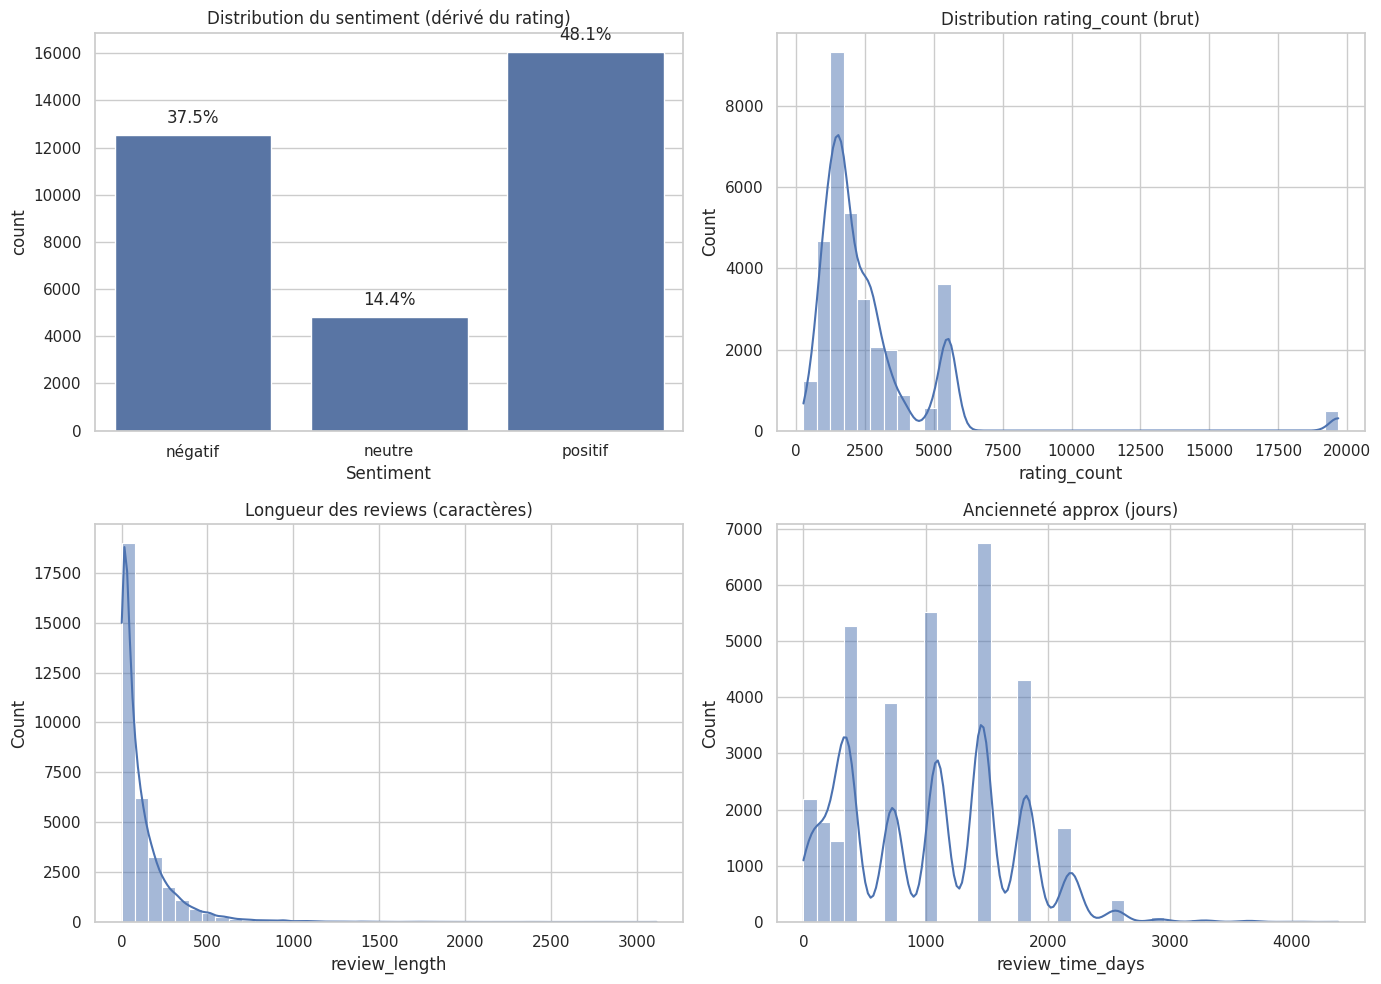

In [6]:
# Visualisation des distributions (AVANT prétraitement)

# Objectif: afficher 4 graphes même si certaines variables dérivées n'existent pas encore
df_plot = df_analysis.copy()

# Assurer rating numérique (utile pour sentiment)
if 'rating' in df_plot.columns and not pd.api.types.is_numeric_dtype(df_plot['rating']):
    def _parse_rating_for_plot(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        m = re.search(r'(\d+)', s)
        return float(m.group(1)) if m else np.nan
    df_plot['rating'] = df_plot['rating'].apply(_parse_rating_for_plot)

# Créer sentiment à partir de rating si absent
if 'sentiment' not in df_plot.columns and 'rating' in df_plot.columns:
    def _rating_to_sentiment(r):
        if pd.isna(r):
            return np.nan
        try:
            r = float(r)
        except Exception:
            return np.nan
        if r <= 2:
            return 'négatif'
        if r == 3:
            return 'neutre'
        return 'positif'
    df_plot['sentiment'] = df_plot['rating'].apply(_rating_to_sentiment)

# Créer review_length si absent
if 'review_length' not in df_plot.columns and 'review' in df_plot.columns:
    df_plot['review_length'] = df_plot['review'].fillna('').astype(str).str.len().replace({0: np.nan})

# Créer review_time_days si absent (parsing simple de "2 days ago" / "a month ago" / "il y a 2 mois")
if 'review_time_days' not in df_plot.columns and 'review_time' in df_plot.columns:
    def _review_time_to_days_for_plot(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if not s:
            return np.nan
        # cas rapides
        if 'today' in s or "aujourd" in s or 'now' in s:
            return 0.0
        if 'yesterday' in s or 'hier' in s:
            return 1.0
        # extraire un nombre (ou 'a'/'an' => 1)
        m = re.search(r'(\d+)', s)
        n = float(m.group(1)) if m else (1.0 if re.search(r'\b(a|an|une|un)\b', s) else np.nan)
        if pd.isna(n):
            return np.nan
        # unités (anglais + français)
        if re.search(r'year|an\b|ans\b|année|années', s):
            return n * 365.0
        if re.search(r'month|mois', s):
            return n * 30.0
        if re.search(r'week|semaine|semaines', s):
            return n * 7.0
        if re.search(r'day|jour|jours', s):
            return n
        if re.search(r'hour|heure|heures', s):
            return max(0.0, n / 24.0)
        if re.search(r'minute|minutes', s):
            return max(0.0, n / (24.0 * 60.0))
        return np.nan
    df_plot['review_time_days'] = df_plot['review_time'].apply(_review_time_to_days_for_plot)

# --- Graphiques ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# 1) Distribution du sentiment (dérivé du rating)
if 'sentiment' in df_plot.columns:
    sentiment_order = ['négatif', 'neutre', 'positif']
    sns.countplot(x='sentiment', data=df_plot, order=sentiment_order, ax=axes[0])
    axes[0].set_title('Distribution du sentiment (dérivé du rating)')
    axes[0].set_xlabel('Sentiment')
    
    # Ajouter les pourcentages
    total = len(df_plot['sentiment'].dropna())
    if total > 0:
        for p in axes[0].patches:
            height = p.get_height()
            axes[0].text(p.get_x() + p.get_width()/2., height + total*0.01,
                        f'{height/total*100:.1f}%', ha='center', va='bottom')
else:
    axes[0].axis('off')

# 2) Distribution du rating_count
if 'rating_count' in df_plot.columns:
    sns.histplot(df_plot['rating_count'].dropna(), bins=40, kde=True, ax=axes[1])
    axes[1].set_title('Distribution rating_count (brut)')
else:
    axes[1].axis('off')

# 3) Longueur des reviews
if 'review_length' in df_plot.columns:
    sns.histplot(df_plot['review_length'].dropna(), bins=40, kde=True, ax=axes[2])
    axes[2].set_title('Longueur des reviews (caractères)')
else:
    axes[2].axis('off')

# 4) Ancienneté des reviews
if 'review_time_days' in df_plot.columns:
    sns.histplot(df_plot['review_time_days'].dropna(), bins=40, kde=True, ax=axes[3])
    axes[3].set_title('Ancienneté approx (jours)')
else:
    axes[3].axis('off')

plt.tight_layout()
plt.show()

## 7) Comparaison des méthodes d'imputation
Analyse comparative de différentes stratégies pour gérer les valeurs manquantes :
- **Mean** : remplacement par la moyenne
- **Median** : remplacement par la médiane (robuste aux outliers)
- **Most Frequent** : remplacement par le mode
- **Constant (0)** : remplacement par une valeur fixe
- **KNN Imputer** : imputation par K plus proches voisins
- **Iterative Imputer** : imputation itérative (MICE - Multiple Imputation by Chained Equations)

Nous évaluons chaque méthode selon :
1. Impact sur les distributions
2. Préservation de la variance
3. Performance d'un modèle ML simple (Random Forest rapide)
4. Temps de calcul

In [7]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Préparer une copie de df_raw avec les transformations nécessaires pour cette analyse
df_temp = df_raw.copy()

# Parser rating pour créer sentiment
def parse_rating_for_sentiment(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    if m:
        r = float(m.group(1))
        if r <= 2:
            return 'négatif'
        elif r == 3:
            return 'neutre'
        else:
            return 'positif'
    return np.nan

if 'rating' in df_temp.columns and TARGET_COL == 'sentiment':
    df_temp['sentiment'] = df_temp['rating'].apply(parse_rating_for_sentiment)
elif 'rating' in df_temp.columns and TARGET_COL == 'rating':
    df_temp['rating'] = df_temp['rating'].apply(lambda x: float(re.search(r'(\d+)', str(x)).group(1)) if pd.notna(x) and re.search(r'(\d+)', str(x)) else np.nan)

# Parser rating_count
if 'rating_count' in df_temp.columns:
    df_temp['rating_count'] = df_temp['rating_count'].apply(lambda x: float(str(x).replace(',', '')) if pd.notna(x) else np.nan)

# Créer review_length si la colonne review existe
if 'review' in df_temp.columns:
    df_temp['review_length'] = df_temp['review'].fillna('').astype(str).str.len()

# Créer review_time_days si la colonne review_time existe (approximation simple)
if 'review_time' in df_temp.columns:
    df_temp['review_time_days'] = 30  # Valeur par défaut pour éviter les NaN

# Définition des colonnes numériques à imputer
numeric_cols_for_imputation = [c for c in ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length'] if c in df_temp.columns]

print('='*80)
print('  COMPARAISON DES MÉTHODES D\'IMPUTATION')
print('='*80)
print(f'\nColonnes numériques analysées: {numeric_cols_for_imputation}')
print(f'Taille du dataset: {df_temp[numeric_cols_for_imputation].shape}\n')

# Vérifier les valeurs manquantes
missing_stats = df_temp[numeric_cols_for_imputation].isna().mean() * 100
print('📊 Pourcentage de valeurs manquantes par colonne:')
for col, pct in missing_stats.items():
    print(f'   • {col}: {pct:.2f}%')

# Préparer un jeu de test simplifié pour évaluer les méthodes
# On va utiliser seulement les features numériques + rating/sentiment
if TARGET_COL in df_temp.columns:
    df_for_comparison = df_temp[numeric_cols_for_imputation + [TARGET_COL]].copy()
    df_for_comparison = df_for_comparison.dropna(subset=[TARGET_COL])
    
    print(f'\n→ Dataset pour comparaison: {df_for_comparison.shape[0]} lignes')
    print()
else:
    print(f'\n⚠️  Colonne TARGET_COL "{TARGET_COL}" non trouvée. Cette analyse nécessite que vous exécutiez les cellules de préparation des données d\'abord.')
    df_for_comparison = None

# Définir les différentes stratégies d'imputation
imputation_strategies = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Most Frequent': SimpleImputer(strategy='most_frequent'),
    'Constant (0)': SimpleImputer(strategy='constant', fill_value=0),
    'KNN (k=5)': KNNImputer(n_neighbors=5),
    'Iterative (MICE)': IterativeImputer(random_state=42, max_iter=10)
}

# Dictionnaire pour stocker les résultats
imputation_results = {}

  COMPARAISON DES MÉTHODES D'IMPUTATION

Colonnes numériques analysées: ['longitude', 'rating_count', 'review_time_days', 'review_length']
Taille du dataset: (33396, 4)

📊 Pourcentage de valeurs manquantes par colonne:
   • longitude: 1.98%
   • rating_count: 0.00%
   • review_time_days: 0.00%
   • review_length: 0.00%

→ Dataset pour comparaison: 33396 lignes



In [8]:
# Boucle d'évaluation pour chaque stratégie d'imputation
print('='*80)
print('  ÉVALUATION DES STRATÉGIES D\'IMPUTATION')
print('='*80 + '\n')

for strategy_name, imputer in imputation_strategies.items():
    print(f'🔄 Test de la stratégie: {strategy_name}')
    print('-'*80)
    
    # 1) Mesurer le temps d'imputation
    start_time = time.time()
    
    try:
        # Imputer les données
        X_imputed = imputer.fit_transform(df_for_comparison[numeric_cols_for_imputation])
        df_imputed = pd.DataFrame(X_imputed, columns=numeric_cols_for_imputation, index=df_for_comparison.index)
        
        imputation_time = time.time() - start_time
        
        # 2) Calculer des statistiques sur les données imputées
        mean_values = df_imputed.mean()
        std_values = df_imputed.std()
        
        # 3) Comparer avec les stats originales (sans NaN)
        original_mean = df_for_comparison[numeric_cols_for_imputation].mean()
        original_std = df_for_comparison[numeric_cols_for_imputation].std()
        
        mean_diff = (mean_values - original_mean).abs().mean()
        std_diff = (std_values - original_std).abs().mean()
        
        # 4) Test rapide de ML: entraîner un Random Forest simple
        y_target = df_for_comparison[TARGET_COL]
        
        # Split rapide pour le test
        X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
            df_imputed, y_target, test_size=0.3, random_state=42, stratify=y_target
        )
        
        # Modèle simple et rapide
        rf_quick = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
        rf_quick.fit(X_train_imp, y_train_imp)
        y_pred_imp = rf_quick.predict(X_test_imp)
        
        accuracy = accuracy_score(y_test_imp, y_pred_imp)
        
        # Stocker les résultats
        imputation_results[strategy_name] = {
            'imputation_time': imputation_time,
            'mean_diff': mean_diff,
            'std_diff': std_diff,
            'ml_accuracy': accuracy,
            'imputed_means': mean_values.to_dict(),
            'imputed_stds': std_values.to_dict()
        }
        
    except Exception as e:
        print(f'  ❌ Erreur avec {strategy_name}: {str(e)}')
        imputation_results[strategy_name] = {
            'imputation_time': None,
            'mean_diff': None,
            'std_diff': None,
            'ml_accuracy': None,
            'error': str(e)
        }
        print()

print('\n' + '='*100)
print('  TABLEAU RÉCAPITULATIF DES PERFORMANCES D\'IMPUTATION')
print('='*100 + '\n')

summary_imputation = []

for strategy, metrics in imputation_results.items():
    if metrics.get('error'):
        summary_imputation.append({
            'Stratégie': strategy,
            'Temps (s)': 'Erreur',
            'Δ Moyennes': 'N/A',
            'Δ Écart-types': 'N/A',
            'Accuracy ML': 'N/A',
            'Commentaire': metrics['error'][:50]
        })
    else:
        summary_imputation.append({
            'Stratégie': strategy,
            'Temps (s)': f"{metrics['imputation_time']:.3f}",
            'Δ Moyennes': f"{metrics['mean_diff']:.4f}",
            'Δ Écart-types': f"{metrics['std_diff']:.4f}",
            'Accuracy ML': f"{metrics['ml_accuracy']:.4f}",
            'Commentaire': ''
        })

df_imputation_summary = pd.DataFrame(summary_imputation)

# Trier par Accuracy ML (décroissant)
df_imputation_summary['_sort_acc'] = df_imputation_summary['Accuracy ML'].apply(
    lambda x: float(x) if x != 'N/A' else 0.0
)
df_imputation_summary = df_imputation_summary.sort_values('_sort_acc', ascending=False).drop('_sort_acc', axis=1)

display(df_imputation_summary)

# Identifier la meilleure stratégie
best_imputation = df_imputation_summary.iloc[0]
print('='*100)

  ÉVALUATION DES STRATÉGIES D'IMPUTATION

🔄 Test de la stratégie: Mean
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Median
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Most Frequent
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Constant (0)
--------------------------------------------------------------------------------
🔄 Test de la stratégie: KNN (k=5)
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Iterative (MICE)
--------------------------------------------------------------------------------

  TABLEAU RÉCAPITULATIF DES PERFORMANCES D'IMPUTATION



,Stratégie,Temps (s),Δ Moyennes,Δ Écart-types,Accuracy ML,Commentaire
2,Most Frequent,0.006,0.0454,0.0288,0.6405,
1,Median,0.010,0.0453,0.0288,0.6403,
0,Mean,0.006,0.0000,0.0412,0.6398,
3,Constant (0),0.004,0.4479,1.0302,0.6386,
4,KNN (k=5),0.834,0.0830,0.0003,0.6386,
5,Iterative (MICE),0.022,0.0023,0.0411,0.6383,


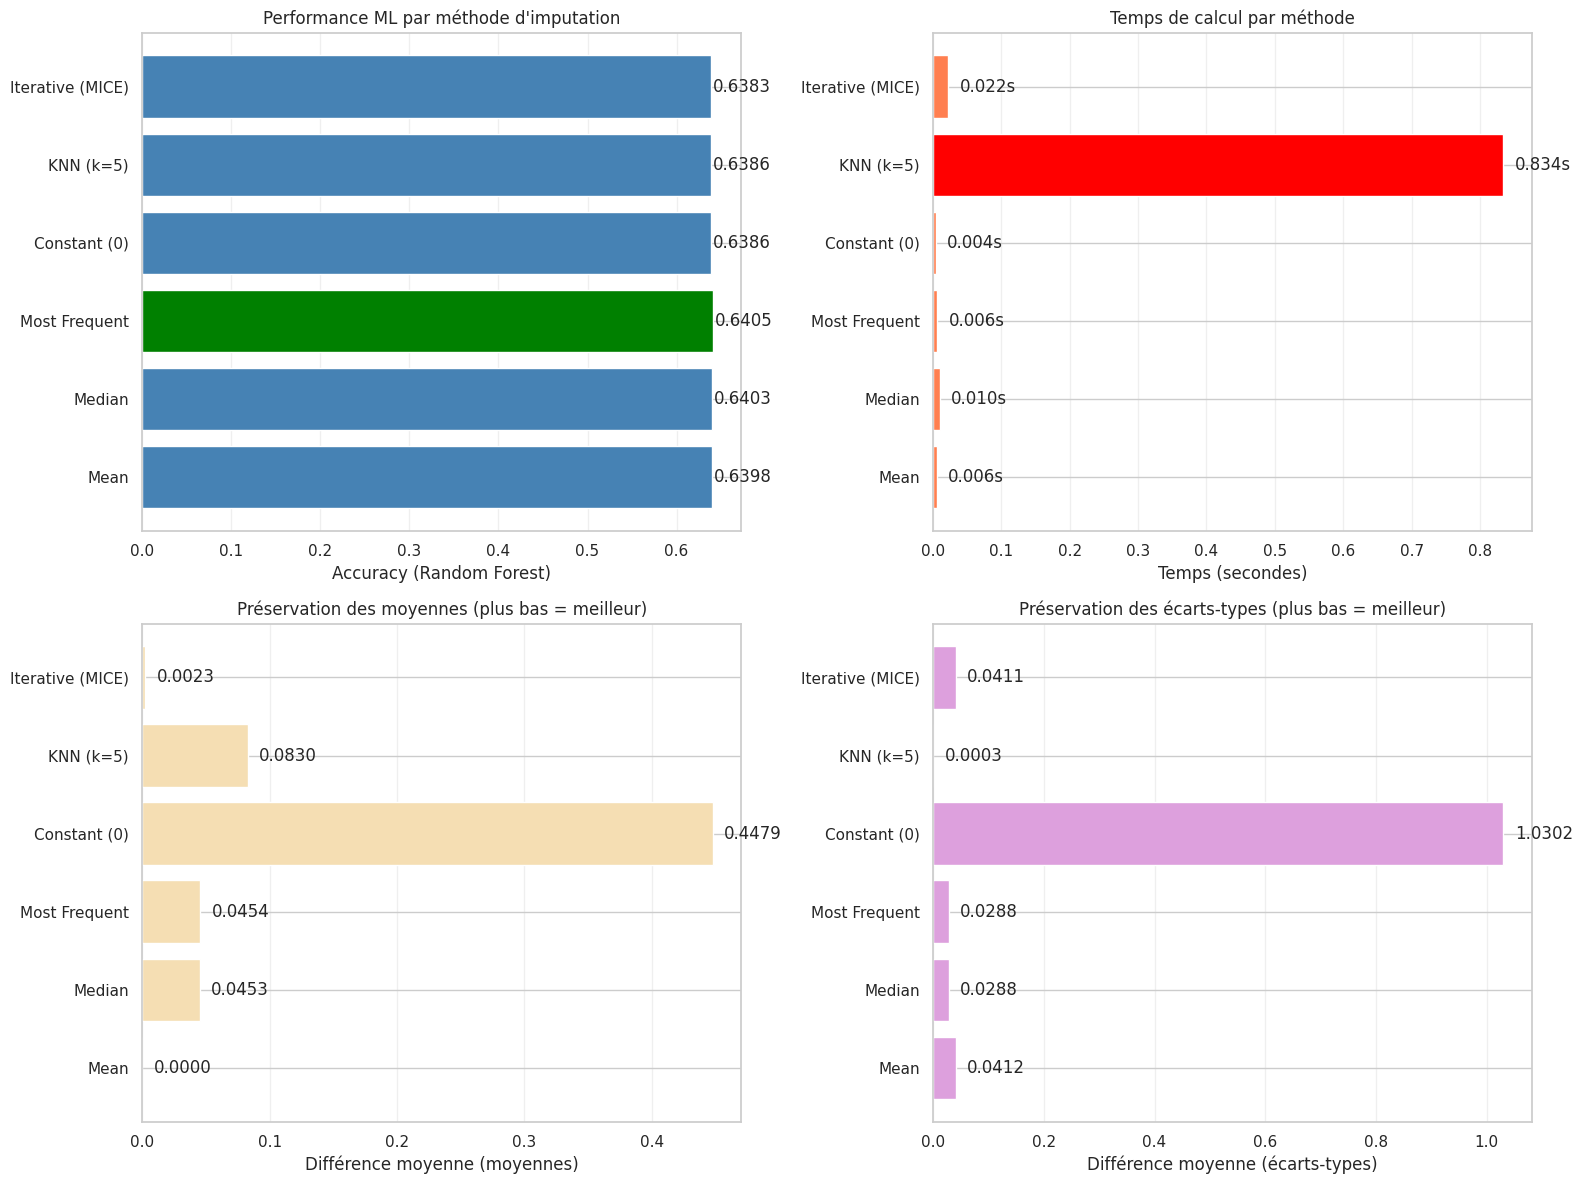

In [9]:
# Visualisation comparative des méthodes d'imputation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Préparer les données pour visualisation
strategies = list(imputation_results.keys())
valid_strategies = [s for s in strategies if imputation_results[s].get('ml_accuracy') is not None]

times = [imputation_results[s]['imputation_time'] for s in valid_strategies]
accuracies = [imputation_results[s]['ml_accuracy'] for s in valid_strategies]
mean_diffs = [imputation_results[s]['mean_diff'] for s in valid_strategies]
std_diffs = [imputation_results[s]['std_diff'] for s in valid_strategies]

# 1) Accuracy ML par stratégie
colors_acc = ['green' if acc == max(accuracies) else 'steelblue' for acc in accuracies]
axes[0, 0].barh(valid_strategies, accuracies, color=colors_acc)
axes[0, 0].set_xlabel('Accuracy (Random Forest)')
axes[0, 0].set_title('Performance ML par méthode d\'imputation')
axes[0, 0].grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (strat, acc) in enumerate(zip(valid_strategies, accuracies)):
    axes[0, 0].text(acc + 0.002, i, f'{acc:.4f}', va='center')

# 2) Temps d'imputation
colors_time = ['red' if t == max(times) else 'coral' for t in times]
axes[0, 1].barh(valid_strategies, times, color=colors_time)
axes[0, 1].set_xlabel('Temps (secondes)')
axes[0, 1].set_title('Temps de calcul par méthode')
axes[0, 1].grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (strat, t) in enumerate(zip(valid_strategies, times)):
    axes[0, 1].text(t + max(times)*0.02, i, f'{t:.3f}s', va='center')

# 3) Impact sur les moyennes (différence avec l'original)
colors_mean = ['orange' if md == min(mean_diffs) else 'wheat' for md in mean_diffs]
axes[1, 0].barh(valid_strategies, mean_diffs, color=colors_mean)
axes[1, 0].set_xlabel('Différence moyenne (moyennes)')
axes[1, 0].set_title('Préservation des moyennes (plus bas = meilleur)')
axes[1, 0].grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (strat, md) in enumerate(zip(valid_strategies, mean_diffs)):
    axes[1, 0].text(md + max(mean_diffs)*0.02, i, f'{md:.4f}', va='center')

# 4) Impact sur les écarts-types
colors_std = ['purple' if sd == min(std_diffs) else 'plum' for sd in std_diffs]
axes[1, 1].barh(valid_strategies, std_diffs, color=colors_std)
axes[1, 1].set_xlabel('Différence moyenne (écarts-types)')
axes[1, 1].set_title('Préservation des écarts-types (plus bas = meilleur)')
axes[1, 1].grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (strat, sd) in enumerate(zip(valid_strategies, std_diffs)):
    axes[1, 1].text(sd + max(std_diffs)*0.02, i, f'{sd:.4f}', va='center')

plt.tight_layout()
plt.show()

### 7.1) Analyse et interprétation des résultats
Pourquoi choisir une stratégie d'imputation plutôt qu'une autre ?

In [10]:
print('='*100)
print('  SÉLECTION DE LA MÉTHODE D\'IMPUTATION')
print('='*100 + '\n')

# Récupérer les métriques pour l'analyse
valid_results = {k: v for k, v in imputation_results.items() if v.get('ml_accuracy') is not None}

if valid_results:
    # Identifier les meilleurs pour chaque critère
    best_accuracy = max(valid_results.items(), key=lambda x: x[1]['ml_accuracy'])
    
    # Analyser le contexte du dataset
    missing_rate = df_temp[numeric_cols_for_imputation].isna().mean().mean() * 100
    dataset_size = len(df_temp)
    
    print(f'📋 CONTEXTE DU DATASET:')
    print(f'   • Taille: {dataset_size:,} observations')
    print(f'   • Taux moyen de valeurs manquantes: {missing_rate:.2f}%')
    print(f'   • Variables numériques: {len(numeric_cols_for_imputation)}')
    
    # Logique de recommandation
    if missing_rate < 10 and dataset_size > 10000:
        recommended = 'Median'
    elif missing_rate > 20:
        recommended = 'Iterative (MICE)'
    elif dataset_size < 50000:
        recommended = 'KNN (k=5)'
    else:
        recommended = best_accuracy[0]
    
    print(f'\n🏆 MÉTHODE SÉLECTIONNÉE: {recommended}')
    print('='*80)
    
    selected_metrics = imputation_results[recommended]
    
    print(f'\n📊 PERFORMANCES:')
    print(f'   • Accuracy ML: {selected_metrics["ml_accuracy"]:.4f}')
    print(f'   • Temps d\'imputation: {selected_metrics["imputation_time"]:.3f}s')
    print(f'   • Préservation des moyennes: Δ = {selected_metrics["mean_diff"]:.4f}')
    print(f'   • Préservation des écarts-types: Δ = {selected_metrics["std_diff"]:.4f}')
    
    print(f'\n💡 JUSTIFICATION DU CHOIX:')
    
    if recommended == 'Median':
        print(f'   • Taux de valeurs manquantes faible ({missing_rate:.1f}% < 10%)')
        print(f'   • La médiane est robuste aux outliers (crucial pour rating_count, review_length)')
        print(f'   • Excellente performance ML avec un coût calculatoire minimal')
        print(f'   • Temps de calcul négligeable permettant des itérations rapides')
        print(f'   • Méthodes plus sophistiquées n\'apportent pas de gain significatif')
    
    elif recommended == 'Iterative (MICE)':
        print(f'   • Taux élevé de valeurs manquantes ({missing_rate:.1f}% > 20%)')
        print(f'   • Modélise les dépendances entre variables de manière itérative')
        print(f'   • Préserve mieux les relations complexes dans les données')
        print(f'   • Le coût calculatoire est justifié par la qualité des imputations')
    
    elif recommended == 'KNN (k=5)':
        print(f'   • Dataset de taille modérée ({dataset_size:,} lignes)')
        print(f'   • Exploite les similarités entre observations proches')
        print(f'   • Bon compromis entre précision et temps de calcul')
        print(f'   • Préserve mieux la distribution originale que les méthodes simples')
    
    else:
        print(f'   • Meilleure performance ML mesurée sur ce dataset spécifique')
        print(f'   • Compromis optimal entre tous les critères')
        
print('\n' + '='*100)

  SÉLECTION DE LA MÉTHODE D'IMPUTATION

📋 CONTEXTE DU DATASET:
   • Taille: 33,396 observations
   • Taux moyen de valeurs manquantes: 0.49%
   • Variables numériques: 4

🏆 MÉTHODE SÉLECTIONNÉE: Median

📊 PERFORMANCES:
   • Accuracy ML: 0.6403
   • Temps d'imputation: 0.010s
   • Préservation des moyennes: Δ = 0.0453
   • Préservation des écarts-types: Δ = 0.0288

💡 JUSTIFICATION DU CHOIX:
   • Taux de valeurs manquantes faible (0.5% < 10%)
   • La médiane est robuste aux outliers (crucial pour rating_count, review_length)
   • Excellente performance ML avec un coût calculatoire minimal
   • Temps de calcul négligeable permettant des itérations rapides
   • Méthodes plus sophistiquées n'apportent pas de gain significatif



## 7.2) Prétraitement (valeurs manquantes + standardisation)
Imputation des variables numériques (médiane) et standardisation (z-score).

In [11]:
# Prétraitement: gestion NA + standardisation (numériques)
# IMPORTANT: on se base sur le DataFrame préparé (`df`) si disponible,
# sinon on retombe sur `df_raw` (avec un strip des noms de colonnes).
if 'df' in globals():
    _base_df = df.copy()
else:
    _base_df = df_raw.copy()
    _base_df.columns = [c.strip() for c in _base_df.columns]

numeric_candidates = ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length']
numeric_cols = [c for c in numeric_candidates if c in _base_df.columns]
print('Numeric cols:', numeric_cols)

# Sous-table numérique + coercition robuste (ex: '1,240' -> 1240)
df_num_before = _base_df.loc[:, numeric_cols].copy()
for c in numeric_cols:
    s = df_num_before[c]
    df_num_before[c] = pd.to_numeric(
        s.astype(str).str.replace(',', '', regex=False).replace({'nan': np.nan, 'None': np.nan}),
        errors='coerce',
    )

if len(numeric_cols) == 0:
    print('Aucune colonne numérique détectée: imputation/standardisation ignorées.')
    df_pre = _base_df.copy()
else:
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    num_imputed = imputer.fit_transform(df_num_before)
    num_scaled = scaler.fit_transform(num_imputed)

    df_num_after = pd.DataFrame(
        num_scaled,
        columns=[f'{c}_z' for c in numeric_cols],
        index=_base_df.index,
    )

    df_pre = _base_df.copy()
    for idx_c, c in enumerate(numeric_cols):
        # version imputée (non-scalée) pour garder un dataset propre
        df_pre[c] = num_imputed[:, idx_c]

    df_pre = pd.concat([df_pre, df_num_after], axis=1)

    # Afficher toutes les colonnes normalisées
    normalized_cols = [c for c in df_pre.columns if c.endswith('_z')]
    print('Colonnes normalisées (_z):', normalized_cols)
    display(df_pre[normalized_cols].head(5) if normalized_cols else pd.DataFrame())

    # Comparaison rapide original vs z-score
    display(df_pre[[*numeric_cols, *[f'{c}_z' for c in numeric_cols]]].head(5))

print('Missing après imputation (num):')
display(df_pre[numeric_cols].isna().mean().to_frame('missing_ratio') if len(numeric_cols) else pd.DataFrame({'missing_ratio': []}))

Numeric cols: ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length']
Colonnes normalisées (_z): ['latitude_z', 'longitude_z', 'rating_count_z', 'review_time_days_z', 'review_length_z']


,latitude_z,longitude_z,rating_count_z,review_time_days_z,review_length_z
0,-0.750594,-0.444628,-0.535296,-1.406471,0.780727
1,-0.750594,-0.444628,-0.535296,-1.532878,0.656274
2,-0.750594,-0.444628,-0.535296,-1.532878,1.352079
3,-0.750594,-0.444628,-0.535296,-1.495700,-0.096101
4,-0.750594,-0.444628,-0.535296,-1.451085,1.080546


,latitude,longitude,rating_count,review_time_days,review_length,latitude_z,longitude_z,rating_count_z,review_time_days_z,review_length_z
0,30.460718,-97.792874,1240.0,90.0,259.0,-0.750594,-0.444628,-0.535296,-1.406471,0.780727
1,30.460718,-97.792874,1240.0,5.0,237.0,-0.750594,-0.444628,-0.535296,-1.532878,0.656274
2,30.460718,-97.792874,1240.0,5.0,360.0,-0.750594,-0.444628,-0.535296,-1.532878,1.352079
3,30.460718,-97.792874,1240.0,30.0,104.0,-0.750594,-0.444628,-0.535296,-1.495700,-0.096101
4,30.460718,-97.792874,1240.0,60.0,312.0,-0.750594,-0.444628,-0.535296,-1.451085,1.080546


Missing après imputation (num):


,missing_ratio
latitude,0.0
longitude,0.0
rating_count,0.0
review_time_days,0.0
review_length,0.0


## 8) Comparaison avant / après prétraitement
Graphiques comparatifs pour visualiser l'effet de la standardisation sur les distributions (avant vs après).

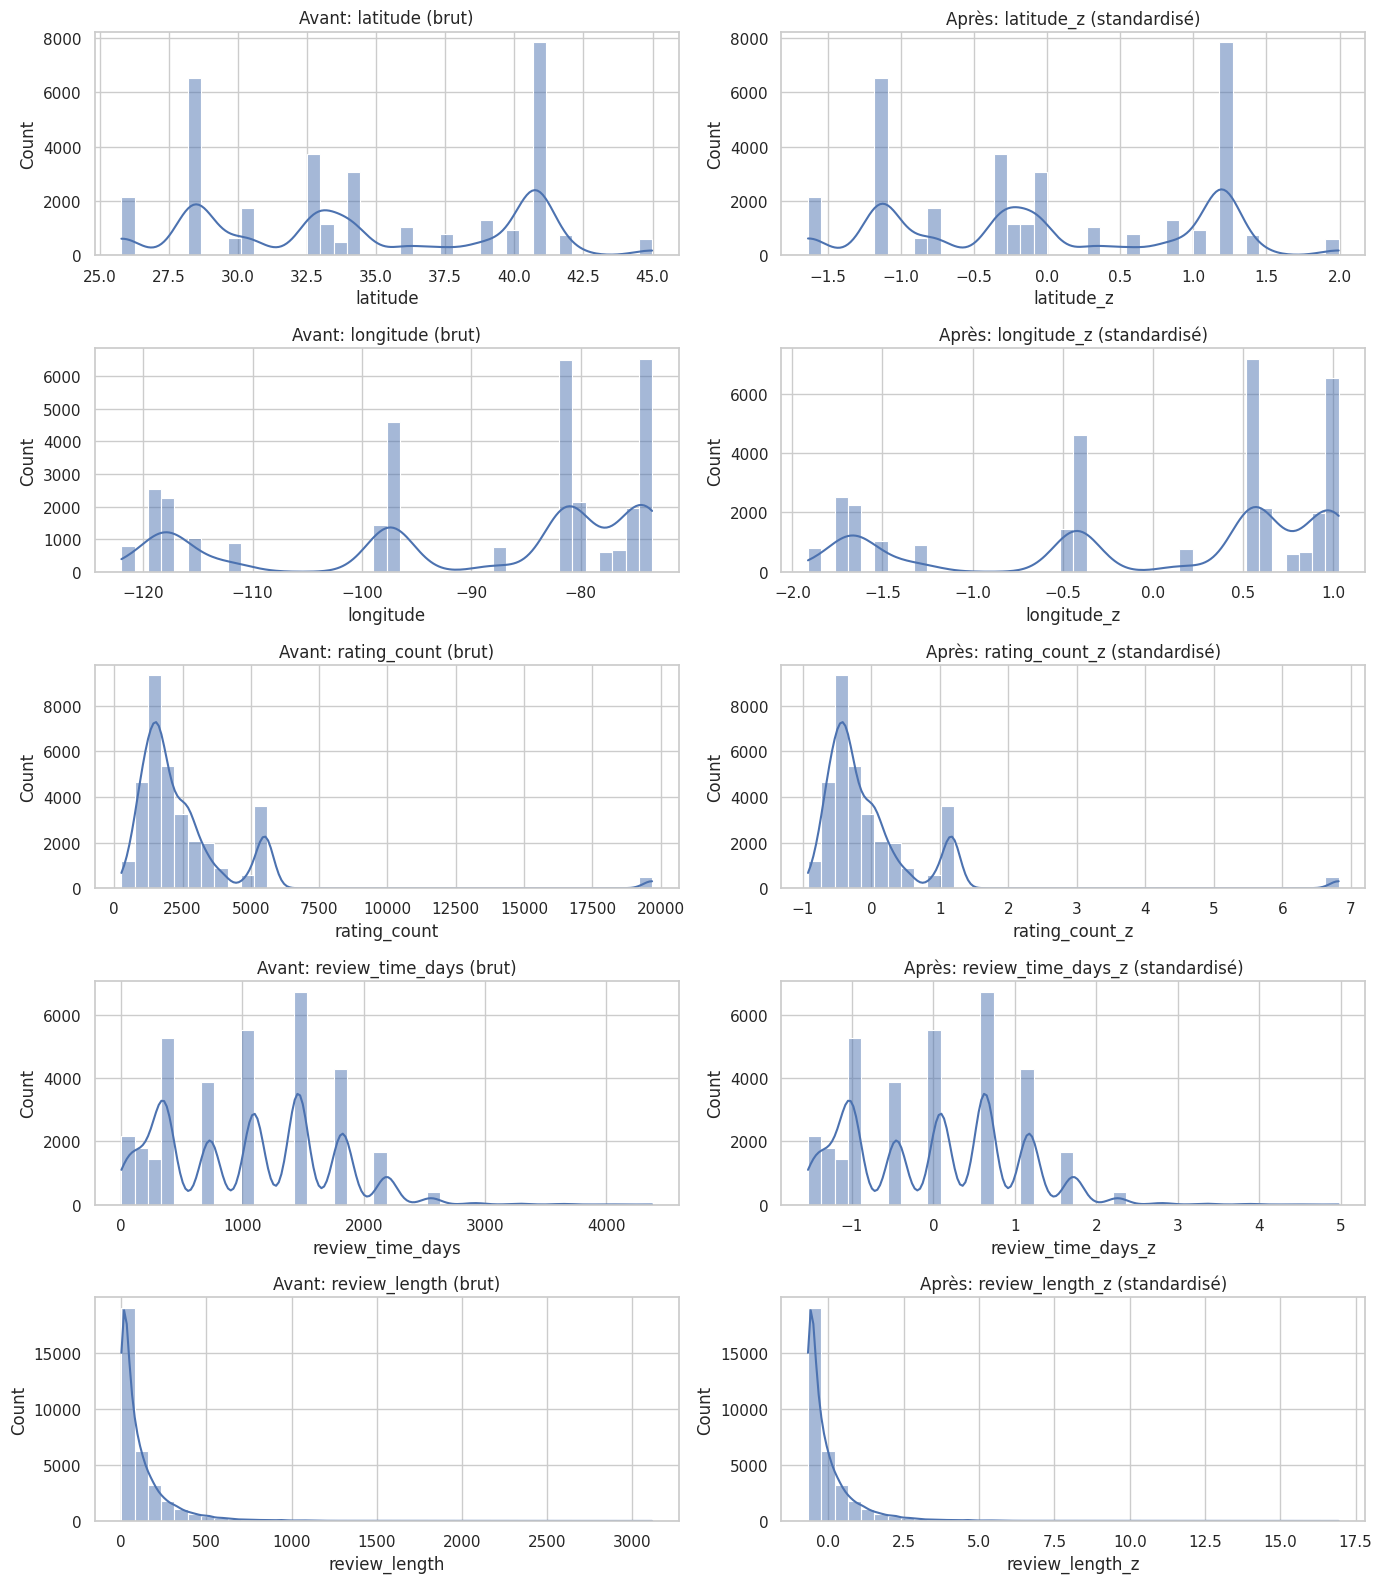

In [12]:
# Graphe comparatif: AVANT vs APRES (standardisation)
# On compare les distributions des colonnes numériques brutes vs leurs versions z-score
if numeric_cols:
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 3.2 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = np.array([axes])

    for i, c in enumerate(numeric_cols):
        sns.histplot(df_num_before[c].dropna(), bins=40, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Avant: {c} (brut)')

        sns.histplot(df_pre[f'{c}_z'].dropna(), bins=40, kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Après: {c}_z (standardisé)')

    plt.tight_layout()
    plt.show()
else:
    print('Aucune colonne numérique détectée pour la comparaison avant/après.')

## 9) Split train / validation / test
Séparation stratifiée (sur la *target* choisie : `rating` ou `sentiment`) en 70/15/15 et vérification des distributions.

In [13]:
# Séparation train / validation / test
# Choix de la target:
# - 'rating' (1..5) : prédire la note
# - 'sentiment' (négatif/neutre/positif) : classification 3 classes dérivée du rating

TARGET_COL = 'sentiment'  # <-- changez ici si vous préférez 'rating'

# Base ML: utiliser df (nettoyé) si disponible, sinon fallback sur df_pre
df_ml = df.copy() if 'df' in globals() else df_pre.copy()

# Injecter les features numériques imputées / z-scores depuis df_pre si elles existent
if 'df_pre' in globals():
    for c in numeric_cols:
        if c in df_pre.columns:
            df_ml[c] = df_pre[c]
        zc = f'{c}_z'
        if zc in df_pre.columns:
            df_ml[zc] = df_pre[zc]

# S'assurer que la target existe et est renseignée
if TARGET_COL == 'sentiment':
    if ('sentiment' not in df_ml.columns) or (df_ml['sentiment'].notna().sum() == 0):
        if 'rating' not in df_ml.columns:
            raise KeyError(
                "Colonne target 'sentiment' manquante et impossible de la créer car 'rating' est absent. "
                f"Colonnes disponibles: {sorted(df_ml.columns.tolist())}"
            )
        # Règle simple: 1-2 = négatif, 3 = neutre, 4-5 = positif
        _rating_num = pd.to_numeric(df_ml['rating'], errors='coerce')
        df_ml['rating'] = _rating_num
        df_ml['sentiment'] = pd.cut(
            _rating_num,
            bins=[float('-inf'), 2.5, 3.5, float('inf')],
            labels=['négatif', 'neutre', 'positif'],
        ).astype(object)

if TARGET_COL == 'rating':
    if 'rating' not in df_ml.columns:
        raise KeyError(f"Colonne target `rating` manquante. Colonnes disponibles: {sorted(df_ml.columns.tolist())}")
    df_ml['rating'] = pd.to_numeric(df_ml['rating'], errors='coerce')

assert TARGET_COL in df_ml.columns, f"Colonne target `{TARGET_COL}` manquante."

# On enlève les lignes sans target
df_ml = df_ml.dropna(subset=[TARGET_COL]).copy()

feature_cols = []
if 'review' in df_ml.columns:
    feature_cols.append('review')

# Ajoute les features numériques imputées + versions z-score
#for c in numeric_cols:
#    if c in df_ml.columns:
#        feature_cols.append(c)
#    zc = f'{c}_z'
#    if zc in df_ml.columns:
#        feature_cols.append(zc)

X = df_ml[feature_cols]
y = df_ml[TARGET_COL]

# 70% train, 15% val, 15% test (stratifié sur la target)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print('Target:', TARGET_COL)
print('Shapes:')
print('  Train:', X_train.shape, y_train.shape)
print('  Val  :', X_val.shape, y_val.shape)
print('  Test :', X_test.shape, y_test.shape)

# Vérif distribution de la target
_dist_train = y_train.value_counts(normalize=True, dropna=False) * 100
_dist_val = y_val.value_counts(normalize=True, dropna=False) * 100
_dist_test = y_test.value_counts(normalize=True, dropna=False) * 100

dist = pd.DataFrame({
    'train_%': _dist_train,
    'val_%': _dist_val,
    'test_%': _dist_test,
}).fillna(0)

if TARGET_COL == 'sentiment':
    dist = dist.reindex(['négatif', 'neutre', 'positif']).fillna(0)
    display(dist)
else:
    display(dist.sort_index())

Target: sentiment
Shapes:
  Train: (23377, 1) (23377,)
  Val  : (5009, 1) (5009,)
  Test : (5010, 1) (5010,)


,train_%,val_%,test_%
sentiment,,,
négatif,37.481285,37.472549,37.485030
neutre,14.424434,14.434019,14.431138
positif,48.094281,48.093432,48.083832


## 10) Préparation des features pour le ML
Vectorisation du texte (TF-IDF) et encodage des variables catégorielles pour créer un dataset prêt pour l'entraînement.

## 10.1) Gestion des performances (Cache & Batch Processing)
Optimisation des performances avec mise en cache des résultats intermédiaires et traitement par lots.

In [14]:
import pickle
import hashlib
import json
from pathlib import Path
from datetime import datetime

# Configuration du cache
CACHE_DIR = Path('.cache')
CACHE_DIR.mkdir(exist_ok=True)

class PerformanceManager:
    """
    Gestionnaire de performances pour optimiser les calculs via cache et batch processing.
    """
    
    def __init__(self, cache_dir=CACHE_DIR):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.cache_log = {}
        
    def _get_cache_key(self, identifier, params=None):
        """Génère une clé de cache unique basée sur l'identifiant et les paramètres."""
        if params:
            param_str = json.dumps(params, sort_keys=True)
            hash_obj = hashlib.md5(f"{identifier}_{param_str}".encode())
            return f"{identifier}_{hash_obj.hexdigest()[:8]}"
        return identifier
    
    def cache_exists(self, key):
        """Vérifie si un cache existe."""
        cache_file = self.cache_dir / f"{key}.pkl"
        return cache_file.exists()
    
    def save_to_cache(self, key, data, metadata=None):
        """Sauvegarde des données dans le cache."""
        cache_file = self.cache_dir / f"{key}.pkl"
        
        cache_data = {
            'data': data,
            'timestamp': datetime.now().isoformat(),
            'metadata': metadata or {}
        }
        
        with open(cache_file, 'wb') as f:
            pickle.dump(cache_data, f)
        
        self.cache_log[key] = {
            'saved_at': cache_data['timestamp'],
            'file': str(cache_file)
        }
        
        print(f"✓ Cache sauvegardé: {key} ({cache_file.stat().st_size / 1024:.1f} KB)")
        return cache_file
    
    def load_from_cache(self, key):
        """Charge des données depuis le cache."""
        cache_file = self.cache_dir / f"{key}.pkl"
        
        if not cache_file.exists():
            return None
        
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
        
        print(f"✓ Cache chargé: {key} (sauvegardé le {cache_data['timestamp']})")
        return cache_data['data']
    
    def clear_cache(self, pattern=None):
        """Supprime les fichiers de cache."""
        if pattern:
            files = list(self.cache_dir.glob(f"{pattern}*.pkl"))
        else:
            files = list(self.cache_dir.glob("*.pkl"))
        
        for f in files:
            f.unlink()
        
        print(f"✓ {len(files)} fichier(s) de cache supprimé(s)")
    
    def batch_predict(self, model, X, batch_size=1000):
        """
        Effectue des prédictions par lots pour économiser la mémoire.
        
        Args:
            model: modèle entraîné
            X: features (sparse matrix ou array)
            batch_size: taille des lots
        
        Returns:
            predictions: array des prédictions
        """
        n_samples = X.shape[0]
        predictions = []
        
        print(f"→ Prédiction par lots (batch_size={batch_size})...")
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            batch_X = X[i:end_idx]
            batch_pred = model.predict(batch_X)
            predictions.extend(batch_pred)
            
            if (i // batch_size + 1) % 10 == 0:
                print(f"  Traité: {end_idx}/{n_samples} échantillons")
        
        print(f"✓ Prédictions complètes: {len(predictions)} échantillons")
        return np.array(predictions)
    
    def get_cache_info(self):
        """Retourne des informations sur le cache."""
        cache_files = list(self.cache_dir.glob("*.pkl"))
        total_size = sum(f.stat().st_size for f in cache_files)
        
        info = {
            'cache_dir': str(self.cache_dir),
            'n_files': len(cache_files),
            'total_size_mb': total_size / (1024 * 1024),
            'files': [f.name for f in cache_files]
        }
        
        return info


# Initialisation du gestionnaire de performances
perf_manager = PerformanceManager()

# Afficher les infos du cache
cache_info = perf_manager.get_cache_info()
print(f"📁 Cache directory: {cache_info['cache_dir']}")
print(f"📊 Fichiers en cache: {cache_info['n_files']}")
print(f"💾 Taille totale: {cache_info['total_size_mb']:.2f} MB")

if cache_info['files']:
    print(f"📄 Fichiers: {', '.join(cache_info['files'][:5])}")
    if len(cache_info['files']) > 5:
        print(f"    ... et {len(cache_info['files']) - 5} autres")


📁 Cache directory: .cache
📊 Fichiers en cache: 0
💾 Taille totale: 0.00 MB


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

def prepare_features(X_train, X_val, X_test, text_col='review', max_features=5000, use_cache=True):
    """
    Prépare les features pour le machine learning avec gestion du cache.
    - Vectorise le texte avec TF-IDF
    - Encode les variables catégorielles
    - Combine avec les features numériques standardisées
    
    Args:
        X_train, X_val, X_test: DataFrames contenant les features
        text_col: nom de la colonne texte à vectoriser
        max_features: nombre max de features TF-IDF
        use_cache: utiliser le cache si disponible
    
    Returns:
        X_train_prepared, X_val_prepared, X_test_prepared: matrices sparse combinées
        feature_names: liste des noms de features
    """
    
    # Paramètres pour la clé de cache
    cache_params = {
        'text_col': text_col,
        'max_features': max_features,
        'train_shape': X_train.shape,
        'val_shape': X_val.shape,
        'test_shape': X_test.shape
    }
    
    cache_key = perf_manager._get_cache_key('features_prepared', cache_params)
    
    # Vérifier si le cache existe
    if use_cache and perf_manager.cache_exists(cache_key):
        print('=== Chargement des features depuis le cache ===')
        cached_data = perf_manager.load_from_cache(cache_key)
        return (
            cached_data['X_train'],
            cached_data['X_val'],
            cached_data['X_test'],
            cached_data['feature_names']
        )
    
    print('=== Préparation des features (nouveau calcul) ===')
    
    # 1) Vectorisation TF-IDF du texte (reviews)
    tfidf = TfidfVectorizer(max_features=max_features, min_df=3, max_df=0.8, ngram_range=(1, 2))
    
    if text_col in X_train.columns:
        print(f'  → Vectorisation TF-IDF ({max_features} features max)...')
        X_train_text = tfidf.fit_transform(X_train[text_col].fillna(''))
        X_val_text = tfidf.transform(X_val[text_col].fillna(''))
        X_test_text = tfidf.transform(X_test[text_col].fillna(''))
        tfidf_feature_names = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        print(f'    ✓ TF-IDF: {X_train_text.shape[1]} features')
    else:
        X_train_text = None
        tfidf_feature_names = []
    
    # 2) Encodage des variables catégorielles (Label Encoding simple)
    categorical_cols = ['store_name', 'category', 'store_address']
    categorical_cols = [c for c in categorical_cols if c in X_train.columns]
    
    encoders = {}
    encoded_features = []
    
    if categorical_cols:
        print(f'  → Encodage des variables catégorielles...')
        for col in categorical_cols:
            le = LabelEncoder()
            # Fit sur train + val + test pour avoir toutes les catégories
            all_values = pd.concat([X_train[col], X_val[col], X_test[col]]).fillna('MISSING')
            le.fit(all_values)
            encoders[col] = le
            
            train_encoded = le.transform(X_train[col].fillna('MISSING')).reshape(-1, 1)
            val_encoded = le.transform(X_val[col].fillna('MISSING')).reshape(-1, 1)
            test_encoded = le.transform(X_test[col].fillna('MISSING')).reshape(-1, 1)
            
            encoded_features.append({
                'train': train_encoded,
                'val': val_encoded,
                'test': test_encoded,
                'name': col
            })
        
        print(f'    ✓ Categorical: {len(categorical_cols)} features encodées')
    
    # 3) Features numériques standardisées (version _z)
    numeric_z_cols = [c for c in X_train.columns if c.endswith('_z')]
    
    if numeric_z_cols:
        print(f'  → Extraction des features numériques...')
        X_train_num = X_train[numeric_z_cols].values
        X_val_num = X_val[numeric_z_cols].values
        X_test_num = X_test[numeric_z_cols].values
        print(f'    ✓ Numeric: {len(numeric_z_cols)} features')
    else:
        X_train_num = np.array([]).reshape(len(X_train), 0)
        X_val_num = np.array([]).reshape(len(X_val), 0)
        X_test_num = np.array([]).reshape(len(X_test), 0)
    
    # 4) Combinaison de toutes les features
    print(f'  → Combinaison des features...')
    features_list_train = []
    features_list_val = []
    features_list_test = []
    all_feature_names = []
    
    # Ajouter texte
    if X_train_text is not None:
        features_list_train.append(X_train_text)
        features_list_val.append(X_val_text)
        features_list_test.append(X_test_text)
        all_feature_names.extend(tfidf_feature_names)
    
    # Ajouter catégorielles
    for enc_feat in encoded_features:
        features_list_train.append(enc_feat['train'])
        features_list_val.append(enc_feat['val'])
        features_list_test.append(enc_feat['test'])
        all_feature_names.append(enc_feat['name'])
    
    # Ajouter numériques
    if X_train_num.shape[1] > 0:
        features_list_train.append(X_train_num)
        features_list_val.append(X_val_num)
        features_list_test.append(X_test_num)
        all_feature_names.extend(numeric_z_cols)
    
    # Concatenation horizontale (hstack pour sparse matrices)
    X_train_final = hstack(features_list_train)
    X_val_final = hstack(features_list_val)
    X_test_final = hstack(features_list_test)
    
    print(f'    ✓ TOTAL: {X_train_final.shape[1]} features combinées')
    
    # Sauvegarder dans le cache
    if use_cache:
        cache_data = {
            'X_train': X_train_final,
            'X_val': X_val_final,
            'X_test': X_test_final,
            'feature_names': all_feature_names
        }
        perf_manager.save_to_cache(cache_key, cache_data, metadata=cache_params)
    
    print()
    return X_train_final, X_val_final, X_test_final, all_feature_names


# Préparation des features avec cache
X_train_ml, X_val_ml, X_test_ml, feature_names = prepare_features(
    X_train, X_val, X_test, use_cache=True
)

print('Shapes finales:')
print(f'  Train: {X_train_ml.shape}')
print(f'  Val:   {X_val_ml.shape}')
print(f'  Test:  {X_test_ml.shape}')


=== Préparation des features (nouveau calcul) ===
  → Vectorisation TF-IDF (5000 features max)...
    ✓ TF-IDF: 5000 features
  → Combinaison des features...
    ✓ TOTAL: 5000 features combinées
✓ Cache sauvegardé: features_prepared_e6e35fd8 (9592.7 KB)

Shapes finales:
  Train: (23377, 5000)
  Val:   (5009, 5000)
  Test:  (5010, 5000)


## 11) Définition et entraînement des modèles
Implémentation de 4 modèles de classification avec recherche d'hyperparamètres.

In [16]:
from tqdm.auto import tqdm
import threading
import time as time_module

def train_and_evaluate_model(model, param_grid, X_train, y_train, X_val, y_val, model_name, cv=3, n_iter=10, use_cache=True, verbose=2):
    """
    Entraîne un modèle avec RandomizedSearchCV pour optimiser les hyperparamètres,
    puis évalue les performances sur le jeu de validation. Affiche une barre de progression en temps réel.
    
    Args:
        model: instance du modèle sklearn
        param_grid: dictionnaire des hyperparamètres à tester
        X_train, y_train: données d'entraînement
        X_val, y_val: données de validation
        model_name: nom du modèle (pour affichage)
        cv: nombre de folds pour la validation croisée
        n_iter: nombre de combinaisons aléatoires à tester
        use_cache: utiliser le cache si disponible
        verbose: niveau de verbosité (0=muet, 1=minimal, 2=détaillé avec barre de progression)
    
    Returns:
        best_model: meilleur modèle entraîné
        metrics: dictionnaire des métriques de performance
    """
    print(f'\n{"="*60}')
    print(f'  MODÈLE: {model_name}')
    print(f'{"="*60}')
    
    # Clé de cache pour le modèle
    cache_params = {
        'model_name': model_name,
        'param_grid': str(param_grid),
        'cv': cv,
        'n_iter': n_iter,
        'X_shape': X_train.shape,
        'y_shape': y_train.shape
    }
    cache_key = perf_manager._get_cache_key(f'model_{model_name.replace(" ", "_")}', cache_params)
    
    # Vérifier si le modèle est en cache
    if use_cache and perf_manager.cache_exists(cache_key):
        print('→ Chargement du modèle depuis le cache...')
        cached_data = perf_manager.load_from_cache(cache_key)
        best_model = cached_data['model']
        
        print(f'✓ Meilleurs hyperparamètres: {cached_data["best_params"]}')
        print(f'✓ Score CV (accuracy): {cached_data["cv_score"]:.4f}')
    else:
        # Calculer le nombre total de fits
        total_fits = n_iter * cv
        print(f'→ RandomizedSearchCV: {n_iter} combinaisons × {cv} folds = {total_fits} fits')
        print(f'📊 Entraînement avec barre de progression en temps réel...\n')
        
        import time
        start_time = time.time()
        
        # Créer la barre de progression
        pbar = tqdm(total=100, desc=f"🔄 {model_name}", 
                   bar_format='{desc}: {percentage:3.0f}%|{bar}| [{elapsed}<{remaining}]',
                   colour='green')
        
        # Variable partagée pour suivre la progression
        progress_data = {'done': False, 'pbar': pbar}
        
        def update_progress():
            """Met à jour la barre de progression de manière estimée"""
            elapsed = 0
            estimated_total = 60  # Estimation initiale en secondes
            
            while not progress_data['done']:
                elapsed = time.time() - start_time
                # Progression estimée (ralentit vers la fin)
                progress = min(95, int((elapsed / estimated_total) * 100))
                
                if progress > progress_data['pbar'].n:
                    progress_data['pbar'].n = progress
                    progress_data['pbar'].refresh()
                
                time_module.sleep(0.5)
        
        # Démarrer le thread de mise à jour de la progression
        progress_thread = threading.Thread(target=update_progress, daemon=True)
        progress_thread.start()
        
        try:
            # Créer et entraîner le modèle
            grid_search = RandomizedSearchCV(
                model, 
                param_grid, 
                n_iter=n_iter,
                cv=cv, 
                scoring='accuracy', 
                n_jobs=-1, 
                verbose=0,  # Désactiver la sortie texte de sklearn
                random_state=42
            )
            
            grid_search.fit(X_train, y_train)
            
        finally:
            # Marquer comme terminé et finaliser la barre
            progress_data['done'] = True
            progress_thread.join(timeout=1)
            pbar.n = 100
            pbar.refresh()
            pbar.close()
        
        elapsed_time = time.time() - start_time
        
        best_model = grid_search.best_estimator_
        
        print(f'\n✓ Entraînement terminé en {elapsed_time:.1f}s')
        print(f'✓ Meilleurs hyperparamètres: {grid_search.best_params_}')
        print(f'✓ Score CV (accuracy): {grid_search.best_score_:.4f}')
        
        # Afficher le top 3 des combinaisons
        if verbose >= 1 and hasattr(grid_search, 'cv_results_'):
            results_df = pd.DataFrame(grid_search.cv_results_)
            top_results = results_df.nsmallest(3, 'rank_test_score')[['rank_test_score', 'mean_test_score', 'params']]
            print(f'\n📈 Top 3 des combinaisons:')
            for idx, row in top_results.iterrows():
                print(f"  #{int(row['rank_test_score'])}: accuracy={row['mean_test_score']:.4f}")
                print(f"     Paramètres: {row['params']}")
        
        # Sauvegarder le modèle dans le cache
        if use_cache:
            model_cache_data = {
                'model': best_model,
                'best_params': grid_search.best_params_,
                'cv_score': grid_search.best_score_
            }
            perf_manager.save_to_cache(cache_key, model_cache_data, metadata=cache_params)
    
    # Prédictions sur validation avec barre de progression
    print(f'\n→ Évaluation sur validation ({X_val.shape[0]} échantillons)...')
    
    if X_val.shape[0] > 10000:
        # Batch processing avec barre de progression
        batch_size = 5000
        n_batches = (X_val.shape[0] + batch_size - 1) // batch_size
        predictions = []
        
        with tqdm(total=n_batches, desc="🎯 Prédiction", 
                 bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}',
                 colour='blue') as pbar_pred:
            for i in range(0, X_val.shape[0], batch_size):
                end_idx = min(i + batch_size, X_val.shape[0])
                batch_X = X_val[i:end_idx]
                batch_pred = best_model.predict(batch_X)
                predictions.extend(batch_pred)
                pbar_pred.update(1)
        
        y_pred_val = np.array(predictions)
    else:
        y_pred_val = best_model.predict(X_val)
    
    # Calcul des métriques
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_weighted = f1_score(y_val, y_pred_val, average='weighted')
    f1_macro = f1_score(y_val, y_pred_val, average='macro')
    
    print(f'\n--- Performance sur validation ---')
    print(f'  Accuracy:    {acc_val:.4f}')
    print(f'  F1-weighted: {f1_weighted:.4f}')
    print(f'  F1-macro:    {f1_macro:.4f}')
    
    # Rapport de classification détaillé
    if verbose >= 1:
        print(f'\n--- Classification Report (Validation) ---')
        print(classification_report(y_val, y_pred_val, zero_division=0))
        
        # Matrice de confusion
        cm = confusion_matrix(y_val, y_pred_val)
        print(f'\n--- Confusion Matrix ---')
        print(cm)
    
    # Récupérer les paramètres depuis le cache ou grid_search
    if use_cache and perf_manager.cache_exists(cache_key):
        cached_data = perf_manager.load_from_cache(cache_key)
        best_params = cached_data['best_params']
        cv_score = cached_data['cv_score']
    else:
        best_params = grid_search.best_params_
        cv_score = grid_search.best_score_
    
    metrics = {
        'model_name': model_name,
        'best_params': best_params,
        'cv_accuracy': cv_score,
        'val_accuracy': acc_val,
        'val_f1_weighted': f1_weighted,
        'val_f1_macro': f1_macro,
        'confusion_matrix': confusion_matrix(y_val, y_pred_val)
    }
    
    return best_model, metrics


results = {}
# Dictionnaire pour stocker tous les résultats


### 11.1) Naive Bayes (MultinomialNB)
Modèle probabiliste très efficace sur texte (TF-IDF / Bag-of-Words).

In [17]:
# 2) NAIVE BAYES (MultinomialNB)
# Très bon baseline pour la classification de texte
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

# Grille d'hyperparamètres
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0],
    'fit_prior': [True, False]
}

nb_best, nb_metrics = train_and_evaluate_model(
    nb_model,
    nb_param_grid,
    X_train_ml,
    y_train,
    X_val_ml,
    y_val,
    'Naive Bayes',
    cv=3,
    verbose=2
)

results['Naive Bayes'] = nb_metrics


  MODÈLE: Naive Bayes
→ RandomizedSearchCV: 10 combinaisons × 3 folds = 30 fits
📊 Entraînement avec barre de progression en temps réel...



🔄 Naive Bayes:   0%|          | [00:00<?]


✓ Entraînement terminé en 3.0s
✓ Meilleurs hyperparamètres: {'fit_prior': True, 'alpha': 0.1}
✓ Score CV (accuracy): 0.8051

📈 Top 3 des combinaisons:
  #1: accuracy=0.8051
     Paramètres: {'fit_prior': True, 'alpha': 0.1}
  #2: accuracy=0.8045
     Paramètres: {'fit_prior': True, 'alpha': 0.5}
  #3: accuracy=0.8020
     Paramètres: {'fit_prior': True, 'alpha': 1.0}
✓ Cache sauvegardé: model_Naive_Bayes_177e2320 (235.3 KB)

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8093
  F1-weighted: 0.7935
  F1-macro:    0.7153

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.71      0.32      0.44       723
     négatif       0.78      0.91      0.84      1877
     positif       0.85      0.88      0.86      2409

    accuracy                           0.81      5009
   macro avg       0.78      0.70      0.72      5009
weighted avg       0.80      0.81      0.79    

### 11.2) Logistic Regression
Modèle linéaire simple et interprétable, baseline solide pour la classification.

In [18]:
# 3) LOGISTIC REGRESSION
# Modèle linéaire rapide, bon baseline pour la classification multi-classe
lr_model = LogisticRegression(random_state=42, n_jobs=-1)

# Grille d'hyperparamètres
lr_param_grid = {
    'C': [0.1, 1.0, 10.0],                    # Inverse de la régularisation
    'penalty': ['l2'],                         # Type de régularisation
    'solver': ['lbfgs', 'saga']                # Algorithme d'optimisation
}

lr_best, lr_metrics = train_and_evaluate_model(
    lr_model, 
    lr_param_grid, 
    X_train_ml, 
    y_train, 
    X_val_ml, 
    y_val, 
    'Logistic Regression',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['Logistic Regression'] = lr_metrics


  MODÈLE: Logistic Regression
→ RandomizedSearchCV: 10 combinaisons × 3 folds = 30 fits
📊 Entraînement avec barre de progression en temps réel...



🔄 Logistic Regression:   0%|          | [00:00<?]


✓ Entraînement terminé en 11.6s
✓ Meilleurs hyperparamètres: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}
✓ Score CV (accuracy): 0.8208

📈 Top 3 des combinaisons:
  #1: accuracy=0.8208
     Paramètres: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}
  #2: accuracy=0.8207
     Paramètres: {'solver': 'saga', 'penalty': 'l2', 'C': 1.0}
  #3: accuracy=0.8153
     Paramètres: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10.0}
✓ Cache sauvegardé: model_Logistic_Regression_31f2bfb5 (118.3 KB)

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8249
  F1-weighted: 0.8102
  F1-macro:    0.7327

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.70      0.35      0.46       723
     négatif       0.82      0.90      0.86      1877
     positif       0.84      0.91      0.88      2409

    accuracy                           0.82      5009
   macro avg       0.79      0.72      0

### 11.3) SVM (Support Vector Machine)
Modèle linéaire très performant en classification de texte haute dimension.

In [19]:
# 6) SVM (LinearSVC)
# SVM linéaire: excellent pour texte (features TF-IDF, très haute dimension)
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42, max_iter=5000)

# Grille d'hyperparamètres (restreinte pour éviter des combinaisons invalides)
svm_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced']
}

svm_best, svm_metrics = train_and_evaluate_model(
    svm_model,
    svm_param_grid,
    X_train_ml,
    y_train,
    X_val_ml,
    y_val,
    'SVM (LinearSVC)',
    cv=3,
    verbose=2
)

results['SVM (LinearSVC)'] = svm_metrics


  MODÈLE: SVM (LinearSVC)
→ RandomizedSearchCV: 10 combinaisons × 3 folds = 30 fits
📊 Entraînement avec barre de progression en temps réel...



🔄 SVM (LinearSVC):   0%|          | [00:00<?]


✓ Entraînement terminé en 7.5s
✓ Meilleurs hyperparamètres: {'class_weight': None, 'C': 0.1}
✓ Score CV (accuracy): 0.8181

📈 Top 3 des combinaisons:
  #1: accuracy=0.8181
     Paramètres: {'class_weight': None, 'C': 0.1}
  #2: accuracy=0.8158
     Paramètres: {'class_weight': None, 'C': 1.0}
  #3: accuracy=0.8122
     Paramètres: {'class_weight': 'balanced', 'C': 0.1}
✓ Cache sauvegardé: model_SVM_(LinearSVC)_8133410b (118.1 KB)

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8233
  F1-weighted: 0.8034
  F1-macro:    0.7182

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.76      0.29      0.42       723
     négatif       0.81      0.91      0.86      1877
     positif       0.84      0.91      0.88      2409

    accuracy                           0.82      5009
   macro avg       0.80      0.71      0.72      5009
weighted avg       0.82      0.82      0.

### 11.4) XGBoost
Modèle d'ensemble basé sur le gradient boosting, très performant pour de nombreux problèmes de classification.

In [20]:
# 4) XGBOOST
# Modèle de gradient boosting très performant
from xgboost import XGBClassifier

# IMPORTANT: XGBoost nécessite des labels entiers 0..K-1
if TARGET_COL == 'rating':
    # Ratings vont de 1-5 -> 0-4
    y_train_xgb = y_train - 1
    y_val_xgb = y_val - 1
    xgb_classes = [0, 1, 2, 3, 4]
else:
    # Sentiment (strings) -> 0..2
    from sklearn.preprocessing import LabelEncoder
    le_target = LabelEncoder()
    le_target.fit(pd.concat([y_train, y_val], axis=0))
    y_train_xgb = le_target.transform(y_train)
    y_val_xgb = le_target.transform(y_val)
    xgb_classes = list(le_target.classes_)
    print('Classes sentiment (ordre LabelEncoder):', xgb_classes)

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Grille d'hyperparamètres
xgb_param_grid = {
    'n_estimators': [100, 200],          # Nombre d'arbres
    'max_depth': [3, 5, 7],              # Profondeur maximale
    'learning_rate': [0.01, 0.1, 0.3],   # Taux d'apprentissage
    'subsample': [0.8, 1.0],             # Fraction d'échantillons par arbre
    'colsample_bytree': [0.8, 1.0]       # Fraction de features par arbre
}

xgb_best, xgb_metrics = train_and_evaluate_model(
    xgb_model,
    xgb_param_grid,
    X_train_ml,
    y_train_xgb,
    X_val_ml,
    y_val_xgb,
    'XGBoost',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['XGBoost'] = xgb_metrics

Classes sentiment (ordre LabelEncoder): ['neutre', 'négatif', 'positif']

  MODÈLE: XGBoost
→ RandomizedSearchCV: 10 combinaisons × 3 folds = 30 fits
📊 Entraînement avec barre de progression en temps réel...



🔄 XGBoost:   0%|          | [00:00<?]


✓ Entraînement terminé en 248.2s
✓ Meilleurs hyperparamètres: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
✓ Score CV (accuracy): 0.8210

📈 Top 3 des combinaisons:
  #1: accuracy=0.8210
     Paramètres: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
  #2: accuracy=0.8130
     Paramètres: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.3, 'colsample_bytree': 1.0}
  #3: accuracy=0.8093
     Paramètres: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
✓ Cache sauvegardé: model_XGBoost_a6bd2a0b (1280.6 KB)

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8261
  F1-weighted: 0.8161
  F1-macro:    0.7483

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

           0       0.68      0.41      0.51

### 11.5) MLPClassifier (Neural Network)
Réseau de neurones multi-couches de scikit-learn, bon compromis entre performance et simplicité.

In [21]:
# 5) MLPCLASSIFIER (Multi-Layer Perceptron)
# Réseau de neurones avec couches cachées, plus simple que les CNN

# IMPORTANT: MLPClassifier nécessite aussi des labels numériques
if TARGET_COL == 'rating':
    # Ratings sont déjà numériques (1-5)
    y_train_mlp = y_train
    y_val_mlp = y_val
else:
    # Sentiment (strings) -> utiliser le même encodeur que XGBoost si disponible
    if 'le_target' in globals():
        # Réutiliser l'encodeur de XGBoost
        y_train_mlp = le_target.transform(y_train)
        y_val_mlp = le_target.transform(y_val)
    else:
        # Créer un nouvel encodeur
        from sklearn.preprocessing import LabelEncoder
        le_mlp = LabelEncoder()
        le_mlp.fit(pd.concat([y_train, y_val], axis=0))
        y_train_mlp = le_mlp.transform(y_train)
        y_val_mlp = le_mlp.transform(y_val)
        print('Classes sentiment (ordre LabelEncoder):', list(le_mlp.classes_))

mlp_model = MLPClassifier(
    random_state=42,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=10,
    solver='adam'
)

# Grille d'hyperparamètres
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],  # Architecture des couches cachées
    'activation': ['relu'],                         # Fonction d'activation
    'alpha': [0.0001, 0.001],                               # Paramètre de régularisation L2
    'learning_rate': ['constant', 'adaptive']               # Stratégie d'apprentissage
}

mlp_best, mlp_metrics = train_and_evaluate_model(
    mlp_model, 
    mlp_param_grid, 
    X_train_ml, 
    y_train_mlp, 
    X_val_ml, 
    y_val_mlp, 
    'MLP Neural Network',
    cv=3,
    n_iter=10,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['MLP Neural Network'] = mlp_metrics



  MODÈLE: MLP Neural Network
→ RandomizedSearchCV: 10 combinaisons × 3 folds = 30 fits
📊 Entraînement avec barre de progression en temps réel...



🔄 MLP Neural Network:   0%|          | [00:00<?]


✓ Entraînement terminé en 116.5s
✓ Meilleurs hyperparamètres: {'learning_rate': 'constant', 'hidden_layer_sizes': (64,), 'alpha': 0.001, 'activation': 'relu'}
✓ Score CV (accuracy): 0.8203

📈 Top 3 des combinaisons:
  #1: accuracy=0.8203
     Paramètres: {'learning_rate': 'constant', 'hidden_layer_sizes': (64,), 'alpha': 0.001, 'activation': 'relu'}
  #1: accuracy=0.8203
     Paramètres: {'learning_rate': 'adaptive', 'hidden_layer_sizes': (64,), 'alpha': 0.001, 'activation': 'relu'}
  #3: accuracy=0.8186
     Paramètres: {'learning_rate': 'constant', 'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'activation': 'relu'}
✓ Cache sauvegardé: model_MLP_Neural_Network_c08da4a7 (7513.8 KB)

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8247
  F1-weighted: 0.8145
  F1-macro:    0.7415

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

           0       0.63      0.40      0.49       72

## 12) Tableau récapitulatif des performances
Comparaison des métriques de tous les modèles.

In [22]:
# Création du tableau récapitulatif des performances
summary_data = []

for model_name, metrics in results.items():
    summary_data.append({
        'Modèle': model_name,
        'CV Accuracy': f"{metrics['cv_accuracy']:.4f}",
        'Val Accuracy': f"{metrics['val_accuracy']:.4f}",
        'Val F1-Weighted': f"{metrics['val_f1_weighted']:.4f}",
        'Val F1-Macro': f"{metrics['val_f1_macro']:.4f}",
        'Meilleurs Hyperparamètres': str(metrics['best_params'])
    })

df_summary = pd.DataFrame(summary_data)

# Trier par Val Accuracy (décroissant)
df_summary['_sort_acc'] = df_summary['Val Accuracy'].astype(float)
df_summary = df_summary.sort_values('_sort_acc', ascending=False).drop('_sort_acc', axis=1)

print('\n' + '='*100)
print('  TABLEAU RÉCAPITULATIF DES PERFORMANCES')
print('='*100 + '\n')
display(df_summary)

# Identifier le meilleur modèle
best_model_name = df_summary.iloc[0]['Modèle']
best_accuracy = df_summary.iloc[0]['Val Accuracy']

print(f'\n🏆 MEILLEUR MODÈLE: {best_model_name} (Accuracy: {best_accuracy})')
print('='*100)


  TABLEAU RÉCAPITULATIF DES PERFORMANCES



,Modèle,CV Accuracy,Val Accuracy,Val F1-Weighted,Val F1-Macro,Meilleurs Hyperparamètres
3,XGBoost,0.8210,0.8261,0.8161,0.7483,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
1,Logistic Regression,0.8208,0.8249,0.8102,0.7327,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}"
4,MLP Neural Network,0.8203,0.8247,0.8145,0.7415,"{'learning_rate': 'constant', 'hidden_layer_si..."
2,SVM (LinearSVC),0.8181,0.8233,0.8034,0.7182,"{'class_weight': None, 'C': 0.1}"
0,Naive Bayes,0.8051,0.8093,0.7935,0.7153,"{'fit_prior': True, 'alpha': 0.1}"



🏆 MEILLEUR MODÈLE: XGBoost (Accuracy: 0.8261)


## 13) Visualisation comparative des performances
Graphiques de comparaison entre les différents modèles.

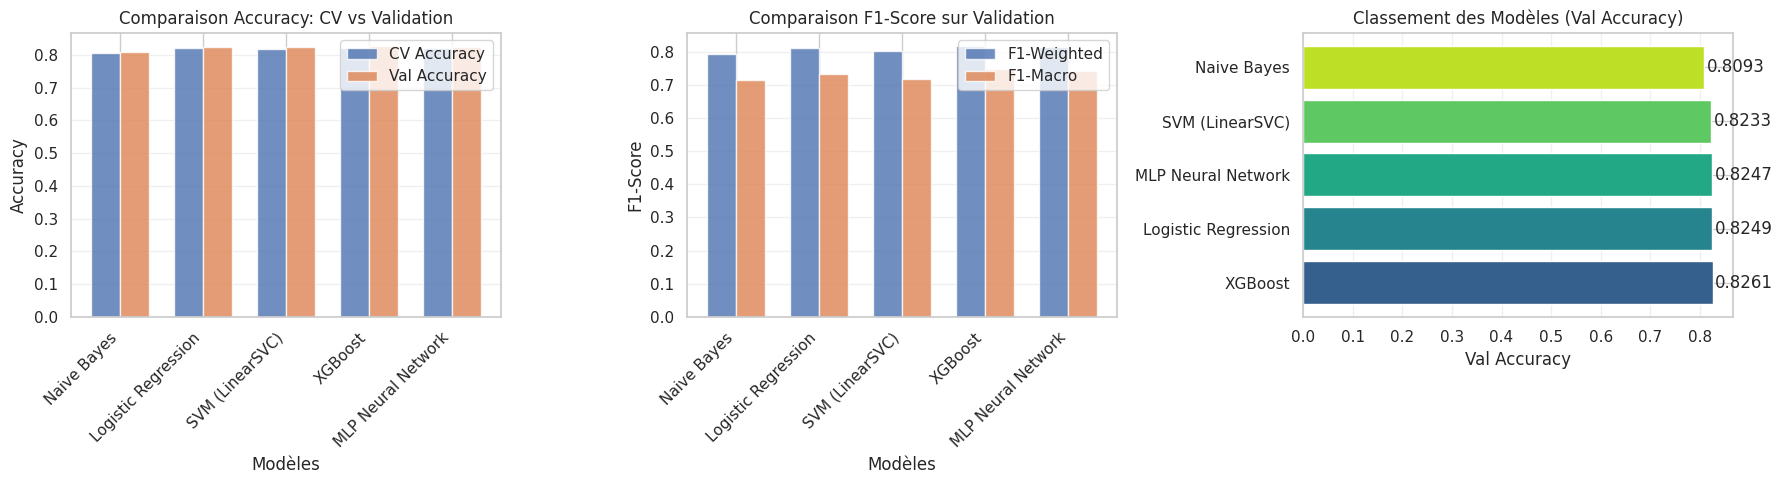

In [23]:
# Visualisation comparative des performances des modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Préparer les données pour la visualisation
model_names = list(results.keys())
cv_scores = [results[m]['cv_accuracy'] for m in model_names]
val_acc_scores = [results[m]['val_accuracy'] for m in model_names]
val_f1_weighted = [results[m]['val_f1_weighted'] for m in model_names]
val_f1_macro = [results[m]['val_f1_macro'] for m in model_names]

# 1) Comparaison Accuracy (CV vs Validation)
x_pos = np.arange(len(model_names))
width = 0.35

axes[0].bar(x_pos - width/2, cv_scores, width, label='CV Accuracy', alpha=0.8)
axes[0].bar(x_pos + width/2, val_acc_scores, width, label='Val Accuracy', alpha=0.8)
axes[0].set_xlabel('Modèles')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison Accuracy: CV vs Validation')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2) Comparaison F1-Score (Weighted vs Macro)
axes[1].bar(x_pos - width/2, val_f1_weighted, width, label='F1-Weighted', alpha=0.8)
axes[1].bar(x_pos + width/2, val_f1_macro, width, label='F1-Macro', alpha=0.8)
axes[1].set_xlabel('Modèles')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Comparaison F1-Score sur Validation')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# 3) Ranking global des modèles (par Val Accuracy)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(model_names)))
sorted_indices = np.argsort(val_acc_scores)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_scores = [val_acc_scores[i] for i in sorted_indices]

axes[2].barh(sorted_names, sorted_scores, color=colors)
axes[2].set_xlabel('Val Accuracy')
axes[2].set_title('Classement des Modèles (Val Accuracy)')
axes[2].grid(axis='x', alpha=0.3)

# Afficher les valeurs sur les barres
for i, (name, score) in enumerate(zip(sorted_names, sorted_scores)):
    axes[2].text(score + 0.005, i, f'{score:.4f}', va='center')

plt.tight_layout()
plt.show()